# 01 - Exploratory Data Analysis
## Chicago Real Estate Dataset

This notebook explores the Chicago real estate dataset to understand:
- Data structure and quality
- Target variable distribution
- Feature correlations
- Time-based patterns
- Missing values

In [1]:
# Setup
import sys
import os
sys.path.insert(0, os.path.join(os.getcwd(), '..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.load_data import load_raw_data
from src.preprocess import split_data_time_based

# Visualization settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline

## 1. Load Data

In [2]:
# Load Chicago real estate data
df = load_raw_data()

print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
df.head()

Dataset shape: (1415, 22)

Columns: ['soldOn', 'type', 'text', 'year_built', 'beds', 'baths', 'baths_full', 'baths_half', 'garage', 'lot_sqft', 'sqft', 'stories', 'property_age', 'sale_year', 'sale_month', 'sale_quarter', 'type_condos', 'type_land', 'type_multi_family', 'type_single_family', 'type_townhomes', 'lastSoldPrice']


,soldOn,type,text,year_built,beds,baths,baths_full,baths_half,garage,lot_sqft,...,property_age,sale_year,sale_month,sale_quarter,type_condos,type_land,type_multi_family,type_single_family,type_townhomes,lastSoldPrice
0,1976-11-09,single_family,Single family home ready for REHAB!! PRICE WAY...,1898.0,5.0,3.0,2.0,1.0,NaN,3025.0,...,78.0,1976,11,4,False,False,False,True,False,20000.0
1,1976-12-08,single_family,Cozy Urban Retreat in the Heart of Lakeview! N...,1895.0,8.0,8.0,7.0,1.0,3.0,5888.0,...,81.0,1976,12,4,False,False,False,True,False,185000.0
2,1977-03-23,single_family,Hello Chatham! All masonry-raised ranch on a b...,1955.0,3.0,2.0,2.0,NaN,2.0,3125.0,...,22.0,1977,3,1,False,False,False,True,False,30000.0
3,1977-04-11,townhomes,Fantastic investment opportunity in the South ...,1962.0,2.0,2.0,1.0,1.0,2.0,759.0,...,15.0,1977,4,2,False,False,False,False,True,19000.0
4,1977-04-19,single_family,Highest and Best offer due by Friday at 5pm Si...,1924.0,3.0,3.0,1.0,2.0,NaN,3900.0,...,53.0,1977,4,2,False,False,False,True,False,33000.0


## 2. Data Overview

In [3]:
# Basic statistics
print("=" * 60)
print("DATA SUMMARY")
print("=" * 60)
print(f"Total properties with sale data: {len(df):,}")
print(f"Date range: {df['soldOn'].min()} to {df['soldOn'].max()}")
print(f"\nTarget variable (lastSoldPrice):")
print(f"  Mean: ${df['lastSoldPrice'].mean():,.2f}")
print(f"  Median: ${df['lastSoldPrice'].median():,.2f}")
print(f"  Std: ${df['lastSoldPrice'].std():,.2f}")
print(f"  Min: ${df['lastSoldPrice'].min():,.2f}")
print(f"  Max: ${df['lastSoldPrice'].max():,.2f}")

DATA SUMMARY
Total properties with sale data: 1,415
Date range: 1976-11-09 00:00:00 to 2024-02-16 00:00:00

Target variable (lastSoldPrice):
  Mean: $368,518.59
  Median: $218,000.00
  Std: $615,689.56
  Min: $600.00
  Max: $7,500,000.00


In [4]:
# Missing values analysis
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Percentage': missing_pct
}).sort_values('Percentage', ascending=False)

print("\nMissing Values:")
print(missing_df[missing_df['Missing Count'] > 0])


Missing Values:
              Missing Count  Percentage
baths_half             1000       70.67
lot_sqft                686       48.48
garage                  495       34.98
sqft                    398       28.13
stories                 226       15.97
property_age            176       12.44
year_built              150       10.60
baths_full               43        3.04
beds                     40        2.83
text                      4        0.28


## 3. Target Variable Distribution

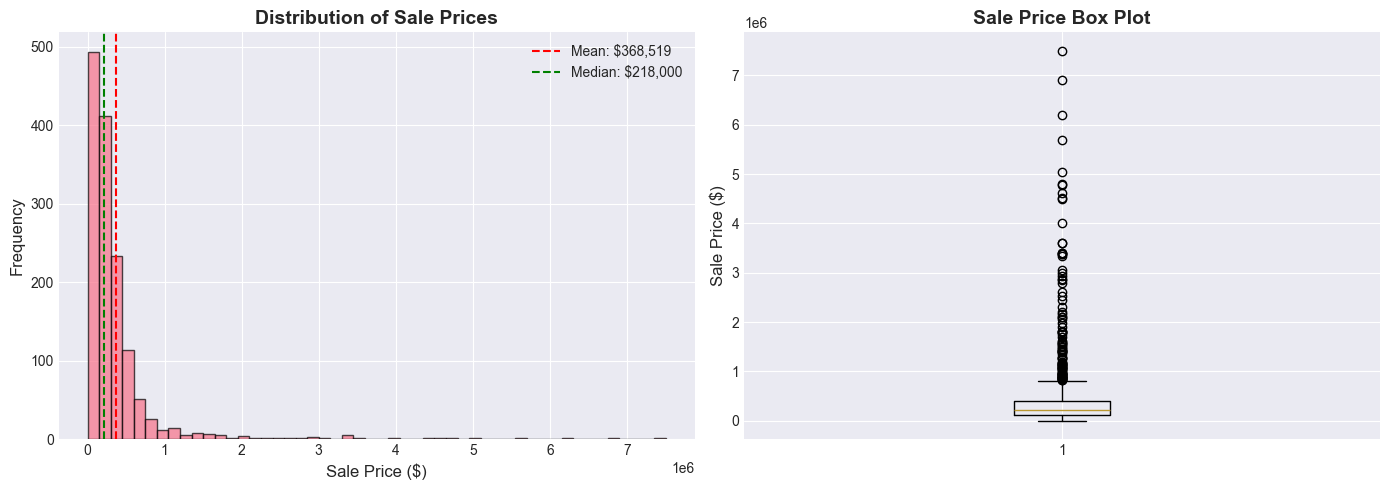


Price Statistics:
  Skewness: 5.91
  Kurtosis: 45.37


In [5]:
# Price distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df['lastSoldPrice'], bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Sale Price ($)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Distribution of Sale Prices', fontsize=14, fontweight='bold')
axes[0].axvline(df['lastSoldPrice'].mean(), color='red', linestyle='--', label=f'Mean: ${df["lastSoldPrice"].mean():,.0f}')
axes[0].axvline(df['lastSoldPrice'].median(), color='green', linestyle='--', label=f'Median: ${df["lastSoldPrice"].median():,.0f}')
axes[0].legend()

# Box plot
axes[1].boxplot(df['lastSoldPrice'], vert=True)
axes[1].set_ylabel('Sale Price ($)', fontsize=12)
axes[1].set_title('Sale Price Box Plot', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nPrice Statistics:")
print(f"  Skewness: {df['lastSoldPrice'].skew():.2f}")
print(f"  Kurtosis: {df['lastSoldPrice'].kurtosis():.2f}")

## 4. Time-Based Analysis

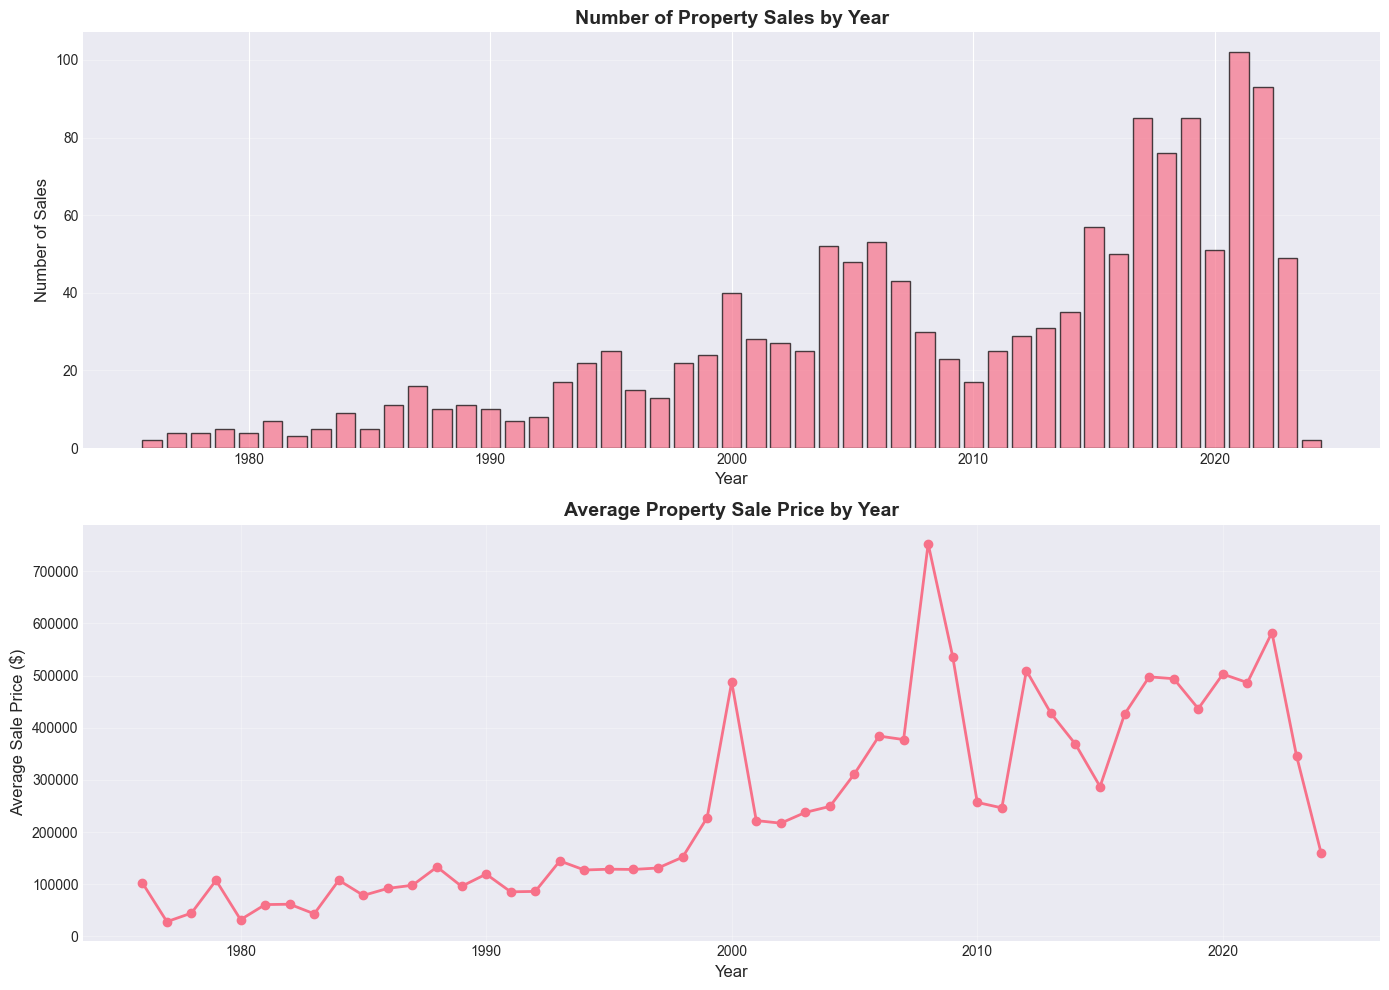

In [6]:
# Sales over time
df_time = df.copy()
df_time['year'] = df_time['soldOn'].dt.year

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Sales count by year
sales_by_year = df_time.groupby('year').size()
axes[0].bar(sales_by_year.index, sales_by_year.values, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Year', fontsize=12)
axes[0].set_ylabel('Number of Sales', fontsize=12)
axes[0].set_title('Number of Property Sales by Year', fontsize=14, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Average price by year
avg_price_by_year = df_time.groupby('year')['lastSoldPrice'].mean()
axes[1].plot(avg_price_by_year.index, avg_price_by_year.values, marker='o', linewidth=2, markersize=6)
axes[1].set_xlabel('Year', fontsize=12)
axes[1].set_ylabel('Average Sale Price ($)', fontsize=12)
axes[1].set_title('Average Property Sale Price by Year', fontsize=14, fontweight='bold')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Train/Test Split Visualization

In [7]:
# Perform time-based split
train_df, test_df = split_data_time_based(df, 'soldOn', train_ratio=0.7)

print("=" * 60)
print("TIME-BASED SPLIT")
print("=" * 60)
print(f"Training set: {len(train_df)} samples")
print(f"  Date range: {train_df['soldOn'].min()} to {train_df['soldOn'].max()}")
print(f"\nTest set: {len(test_df)} samples")
print(f"  Date range: {test_df['soldOn'].min()} to {test_df['soldOn'].max()}")
print(f"\nSplit ratio: {len(train_df)/len(df)*100:.1f}% train, {len(test_df)/len(df)*100:.1f}% test")

Time-based split:
  Train: 990 samples (1976-11-09 00:00:00 to 2018-06-28 00:00:00)
  Test:  425 samples (2018-06-29 00:00:00 to 2024-02-16 00:00:00)
TIME-BASED SPLIT
Training set: 990 samples
  Date range: 1976-11-09 00:00:00 to 2018-06-28 00:00:00

Test set: 425 samples
  Date range: 2018-06-29 00:00:00 to 2024-02-16 00:00:00

Split ratio: 70.0% train, 30.0% test


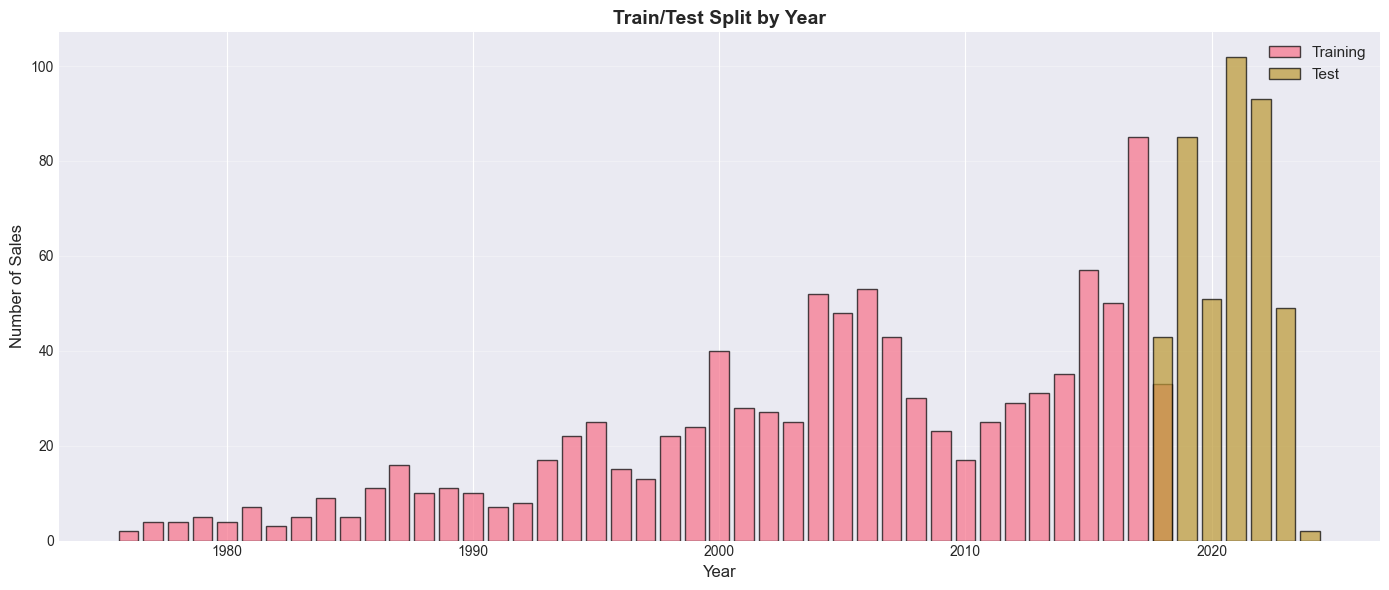

In [8]:
# Visualize split
fig, ax = plt.subplots(figsize=(14, 6))

train_df_plot = train_df.copy()
test_df_plot = test_df.copy()
train_df_plot['year'] = train_df_plot['soldOn'].dt.year
test_df_plot['year'] = test_df_plot['soldOn'].dt.year

train_counts = train_df_plot.groupby('year').size()
test_counts = test_df_plot.groupby('year').size()

ax.bar(train_counts.index, train_counts.values, label='Training', alpha=0.7, edgecolor='black')
ax.bar(test_counts.index, test_counts.values, label='Test', alpha=0.7, edgecolor='black')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Number of Sales', fontsize=12)
ax.set_title('Train/Test Split by Year', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Feature Correlation Analysis

Correlation with Sale Price:
sqft            0.659708
baths           0.532599
baths_full      0.471760
baths_half      0.323112
beds            0.211841
sale_year       0.201712
year_built      0.124556
stories         0.086720
garage          0.054741
lot_sqft        0.032154
property_age   -0.059823
Name: lastSoldPrice, dtype: float64


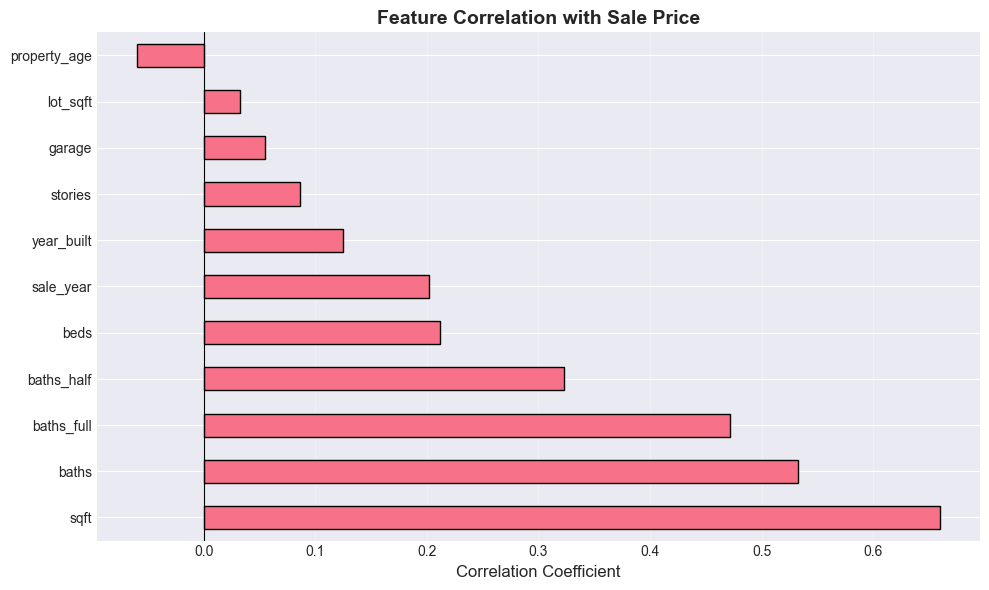

In [9]:
# Select numerical features for correlation
numerical_features = ['year_built', 'beds', 'baths', 'baths_full', 'baths_half', 
                     'garage', 'lot_sqft', 'sqft', 'stories', 'property_age', 
                     'sale_year', 'lastSoldPrice']

available_features = [f for f in numerical_features if f in df.columns]
corr_df = df[available_features].corr()

# Correlation with target
target_corr = corr_df['lastSoldPrice'].drop('lastSoldPrice').sort_values(ascending=False)

print("Correlation with Sale Price:")
print(target_corr)

# Visualize
fig, ax = plt.subplots(figsize=(10, 6))
target_corr.plot(kind='barh', ax=ax, edgecolor='black')
ax.set_xlabel('Correlation Coefficient', fontsize=12)
ax.set_title('Feature Correlation with Sale Price', fontsize=14, fontweight='bold')
ax.axvline(0, color='black', linewidth=0.8)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Property Type Analysis

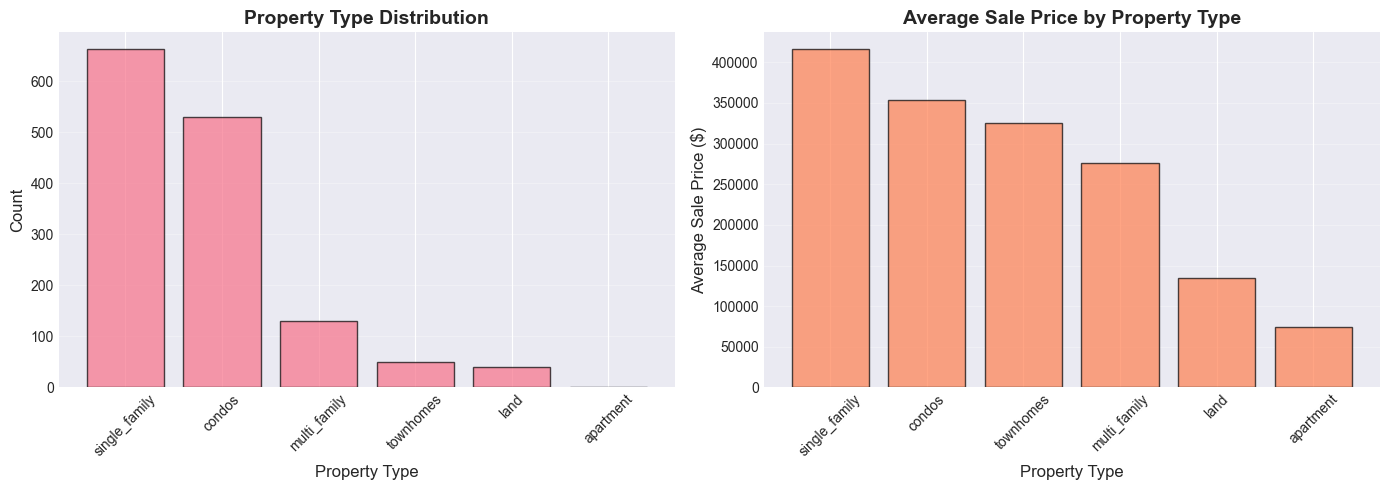


Property Type Statistics:
type
single_family    415982.073906
condos           354123.789077
townhomes        324800.000000
multi_family     276293.846154
land             134619.100000
apartment         75000.000000
Name: lastSoldPrice, dtype: float64


In [10]:
# Property type distribution
if 'type' in df.columns:
    type_counts = df['type'].value_counts()
    type_avg_price = df.groupby('type')['lastSoldPrice'].mean().sort_values(ascending=False)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Count
    axes[0].bar(type_counts.index, type_counts.values, edgecolor='black', alpha=0.7)
    axes[0].set_xlabel('Property Type', fontsize=12)
    axes[0].set_ylabel('Count', fontsize=12)
    axes[0].set_title('Property Type Distribution', fontsize=14, fontweight='bold')
    axes[0].tick_params(axis='x', rotation=45)
    axes[0].grid(axis='y', alpha=0.3)
    
    # Average price
    axes[1].bar(type_avg_price.index, type_avg_price.values, edgecolor='black', alpha=0.7, color='coral')
    axes[1].set_xlabel('Property Type', fontsize=12)
    axes[1].set_ylabel('Average Sale Price ($)', fontsize=12)
    axes[1].set_title('Average Sale Price by Property Type', fontsize=14, fontweight='bold')
    axes[1].tick_params(axis='x', rotation=45)
    axes[1].grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print("\nProperty Type Statistics:")
    print(type_avg_price)

## 8. Key Insights

**Dataset Summary:**
- Total sold properties: 1,415
- Date range: 1976-2024 (48 years)
- Train/Test split: 990 / 425 (70/30)

**Target Variable:**
- Mean price: ~$368K
- Highly skewed distribution (long right tail)
- Significant outliers present

**Top Correlated Features:**
- `sqft`: Strong positive correlation
- `baths`: Strong positive correlation  
- `beds`: Moderate positive correlation

**Missing Data:**
- `sqft`: ~28% missing
- `lot_sqft`: ~48% missing
- Will use median imputation in preprocessing

**Next Steps:**
1. Build baseline models (Mean, OLS)
2. Engineer polynomial features
3. Test regularized models (Ridge, Lasso)
4. Evaluate SVR performance